# VLM Model Testing Notebook

This notebook allows you to test the VLM model with the same prompt used in `Fold_Tops_HALO_mp.py`.


In [14]:
import os
import json
import base64
import re
import cv2
import numpy as np
from openai import OpenAI
from typing import Dict, List, Optional
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage


In [24]:
# VLM Prompt (same as in Fold_Tops_HALO_mp.py)
VLM_FOLD_PROMPT = "<image>\nThe image contains a piece of clothing. Infer the NEXT folding action.\n\nOutput a single JSON array with two objects:\n[\n  { \"plan\": <plan_output> },\n  { \"points\": <points_output> }\n]\n\nPLAN OUTPUT:\n- Either a list containing EXACTLY ONE action (the next step), OR the string \"already finish folding\".\n- If already folded, output:\n[\n  { \"plan\": \"already finish folding\" },\n  { \"points\": [] }\n]\n\nACTION FORMAT (single step):\n{\n  \"left\":  { \"from\": <keypoint>, \"to\": <keypoint> },\n  \"right\": { \"from\": <keypoint>, \"to\": <keypoint> }\n}\n- If an arm is idle: {\"from\": null, \"to\": null}\n\nVALID KEYPOINT NAMES (ONLY THESE 6):\nleft_cuff, right_cuff, left_hem, right_hem, left_shoulder, right_shoulder\n\nPOINTS OUTPUT:\n- \"points\" MUST include ONLY the keypoints referenced by the action in \"plan\".\n- Each entry:\n{ \"label\": \"<keypoint>\", \"bbox\": [x_min, y_min, x_max, y_max] }\n\nSTANDARD SHIRT FOLDING REFERENCE (FULL PLAN FROM A COMPLETELY FLAT, UNFOLDED SHIRT):\nStep 1: left_cuff  -> right_shoulder (right arm idle)\nStep 2: right_cuff -> left_shoulder  (left arm idle)\nStep 3: left_hem -> left_shoulder AND right_hem -> right_shoulder\nIMPORTANT: Use this reference ONLY to decide what the NEXT step should be. Do NOT output all steps.\n\nDo not output anything except the final JSON array.\n"

print("VLM Prompt loaded successfully!")


VLM Prompt loaded successfully!


In [25]:
# Helper Functions
def encode_image_to_data_url(image_path: str) -> str:
    """
    Load an image from file path and encode it to base64 data URL.
    """
    # Read image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Cannot read image from {image_path}")
    
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Encode to PNG
    success, buf = cv2.imencode(".png", cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    if not success:
        raise RuntimeError("Cannot encode image to PNG.")
    
    img_bytes = buf.tobytes()
    img_base64 = base64.b64encode(img_bytes).decode("utf-8")
    return f"data:image/png;base64,{img_base64}"


def parse_vlm_output(raw_text: str) -> Dict[str, object]:
    """
    Parse VLM raw text output and extract plan and points.
    """
    try:
        data = json.loads(raw_text)
    except Exception:
        # Try to find JSON array in the text
        match = re.search(r"\[.*\]", raw_text, re.S)
        if not match:
            raise ValueError(f"Cannot find JSON array in VLM output. Raw output:\n{raw_text}")
        data = json.loads(match.group(0))
    
    if not isinstance(data, list) or len(data) != 2:
        raise ValueError(f"VLM output JSON structure is invalid. Expected list of length 2, got: {data}")
    
    plan_obj = data[0] if isinstance(data[0], dict) else {}
    points_obj = data[1] if isinstance(data[1], dict) else {}
    plan = plan_obj.get("plan", None)
    points = points_obj.get("points", None)
    
    return {"plan": plan, "points": points}


def visualize_result_with_bbox(image_path: str, points: Optional[List[Dict[str, object]]]) -> np.ndarray:
    """
    Visualize the image with bounding boxes from VLM output.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Cannot read image from {image_path}")
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img_rgb.shape[:2]
    
    if points is None or not isinstance(points, list):
        return img_rgb
    
    # Draw bounding boxes
    for item in points:
        if not isinstance(item, dict):
            continue
        
        label = item.get("label")
        bbox = item.get("bbox")
        
        if label is None or bbox is None or not isinstance(bbox, (list, tuple)) or len(bbox) != 4:
            continue
        
        # Convert from 0-1000 range to pixel coordinates
        x_min_rel, y_min_rel, x_max_rel, y_max_rel = [float(v) for v in bbox]
        x_min = int(x_min_rel / 1000.0 * img_w)
        x_max = int(x_max_rel / 1000.0 * img_w)
        y_min = int(y_min_rel / 1000.0 * img_h)
        y_max = int(y_max_rel / 1000.0 * img_h)
        
        # Draw rectangle
        cv2.rectangle(img_rgb, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)
        
        # Put label text
        cv2.putText(
            img_rgb,
            str(label),
            (x_min, max(y_min - 5, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )
    
    return img_rgb

print("Helper functions loaded successfully!")


Helper functions loaded successfully!


In [26]:
# Configuration
# Set your VLM API endpoint and model name
VLM_BASE_URL = "http://localhost:8001/v1"  # Change this to your vLLM server URL
VLM_MODEL_NAME = "/share_data/yanruilin/qwen3vl_full_sft_cloth_4"     # Change this to your model name
VLM_API_KEY = os.environ.get("VLM_API_KEY", "EMPTY")

# Initialize OpenAI client
client = OpenAI(base_url=VLM_BASE_URL, api_key=VLM_API_KEY)

print(f"VLM Client initialized with base_url: {VLM_BASE_URL}")
print(f"Model: {VLM_MODEL_NAME}")


VLM Client initialized with base_url: http://localhost:8001/v1
Model: /share_data/yanruilin/qwen3vl_full_sft_cloth_4


In [52]:
# Main Function: Call VLM with Image
def call_vlm_with_image(image_path: str, max_tokens: int = 1024) -> Dict[str, object]:
    """
    Call VLM model with an image and get folding plan + keypoints.
    
    Args:
        image_path: Path to the input image
        max_tokens: Maximum tokens for model response
    
    Returns:
        Dictionary with 'plan' and 'points' fields
    """
    print(f"Loading image from: {image_path}")
    
    # Encode image to data URL
    image_data_url = encode_image_to_data_url(image_path)
    
    print("Calling VLM model...")
    
    # Call VLM API
    response = client.chat.completions.create(
        model=VLM_MODEL_NAME,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {"url": image_data_url},
                    },
                    {"type": "text", "text": "\n" + VLM_FOLD_PROMPT},
                ],
            }
        ],
        max_tokens=max_tokens,
    )
    
    # Extract raw response
    raw_output = response.choices[0].message.content
    
    print("Parsing VLM output...")
    
    # Parse the output
    result = parse_vlm_output(raw_output)
    
    return result, raw_output

print("Main function loaded successfully!")


Main function loaded successfully!


✓ Image found: Debug/1.png


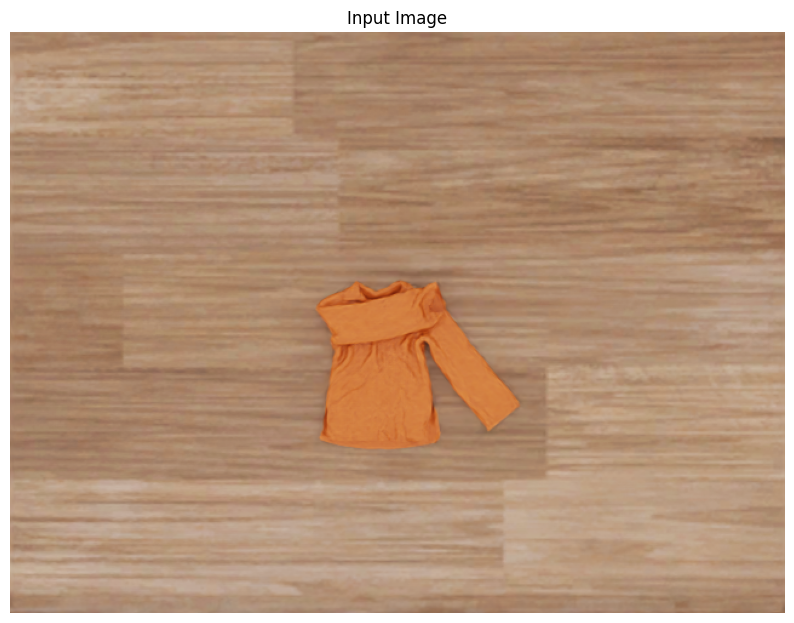

In [53]:
## Usage Example

### Step 1: Set your image path
# Change this to your image path
IMAGE_PATH = "Debug/1.png"

# Check if file exists
if os.path.exists(IMAGE_PATH):
    print(f"✓ Image found: {IMAGE_PATH}")
    # Display the original image
    img = cv2.imread(IMAGE_PATH)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title("Input Image")
    plt.axis('off')
    plt.show()
else:
    print(f"✗ Image not found: {IMAGE_PATH}")
    print("Please update IMAGE_PATH to point to a valid image file.")


In [54]:
### Step 2: Call VLM and get prediction
try:
    result, raw_output = call_vlm_with_image(IMAGE_PATH)
    
    print("\n" + "="*80)
    print("VLM RAW OUTPUT:")
    print("="*80)
    print(raw_output)
    print("="*80)
    
    print("\n" + "="*80)
    print("PARSED RESULT:")
    print("="*80)
    print(json.dumps(result, indent=2, ensure_ascii=False))
    print("="*80)
    
except Exception as e:
    print(f"Error calling VLM: {e}")
    import traceback
    traceback.print_exc()


Loading image from: Debug/1.png
Calling VLM model...
Parsing VLM output...

VLM RAW OUTPUT:
<think>

</think>

[{"plan": [{"left": {"from": null, "to": null}, "right": {"from": "right_cuff", "to": "left_shoulder"}}]}, {"points": [{"label": "right_cuff", "bbox": [622, 641, 641, 666]}, {"label": "left_shoulder", "bbox": [408, 445, 427, 470]}]}]

PARSED RESULT:
{
  "plan": [
    {
      "left": {
        "from": null,
        "to": null
      },
      "right": {
        "from": "right_cuff",
        "to": "left_shoulder"
      }
    }
  ],
  "points": [
    {
      "label": "right_cuff",
      "bbox": [
        622,
        641,
        641,
        666
      ]
    },
    {
      "label": "left_shoulder",
      "bbox": [
        408,
        445,
        427,
        470
      ]
    }
  ]
}


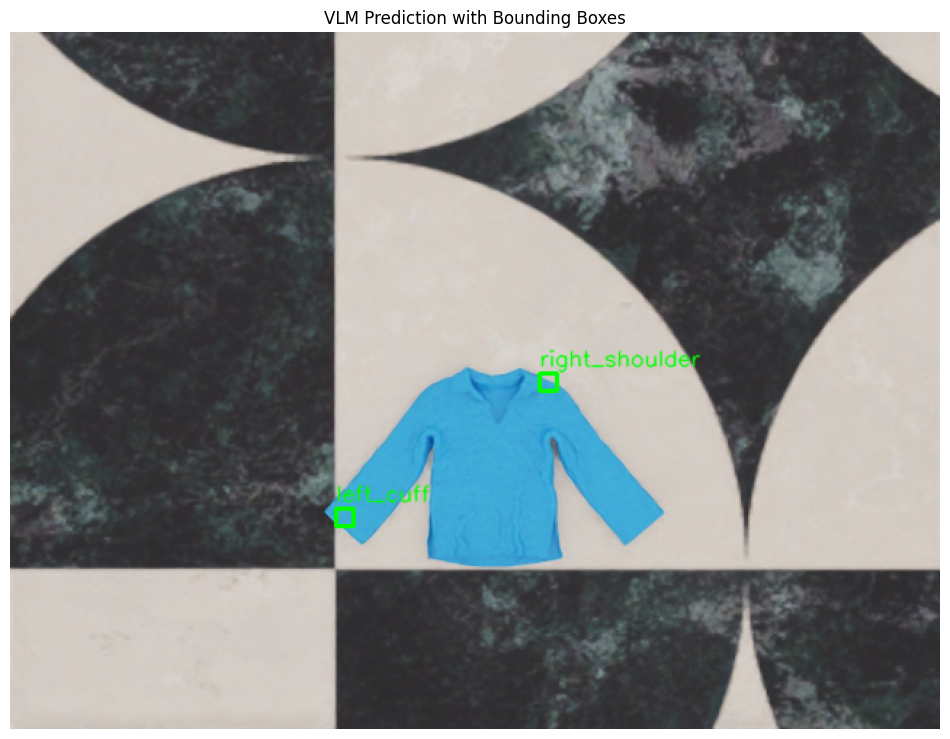


FOLDING PLAN:

Step 1:
  Left arm:  left_cuff → right_shoulder
  Right arm: None → None


In [30]:
### Step 3: Visualize the result with bounding boxes
try:
    # Visualize the image with bounding boxes
    img_with_bbox = visualize_result_with_bbox(IMAGE_PATH, result.get('points'))
    
    # Display the result
    plt.figure(figsize=(12, 10))
    plt.imshow(img_with_bbox)
    plt.title("VLM Prediction with Bounding Boxes")
    plt.axis('off')
    plt.show()
    
    # Print the plan in a readable format
    print("\n" + "="*80)
    print("FOLDING PLAN:")
    print("="*80)
    plan = result.get('plan')
    if isinstance(plan, str):
        print(f"Status: {plan}")
    elif isinstance(plan, list):
        for i, step in enumerate(plan, 1):
            print(f"\nStep {i}:")
            left = step.get('left', {})
            right = step.get('right', {})
            print(f"  Left arm:  {left.get('from')} → {left.get('to')}")
            print(f"  Right arm: {right.get('from')} → {right.get('to')}")
    print("="*80)
    
except Exception as e:
    print(f"Error visualizing result: {e}")
    import traceback
    traceback.print_exc()


In [ ]:
## Optional: Test with a different image
# Uncomment and modify the following lines to test with another image

# IMAGE_PATH_2 = "path/to/your/image.png"
# result_2, raw_output_2 = call_vlm_with_image(IMAGE_PATH_2)
# print(json.dumps(result_2, indent=2, ensure_ascii=False))
# 
# img_with_bbox_2 = visualize_result_with_bbox(IMAGE_PATH_2, result_2.get('points'))
# plt.figure(figsize=(12, 10))
# plt.imshow(img_with_bbox_2)
# plt.title("VLM Prediction 2")
# plt.axis('off')
# plt.show()
